<a href="https://colab.research.google.com/github/manaswinisxccal/Bifurcation-Analysis/blob/main/Bifurcational_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated saddle-node dose: D_crit = 1.4748
Collision point: T* = 0.4765, E* = 0.6933


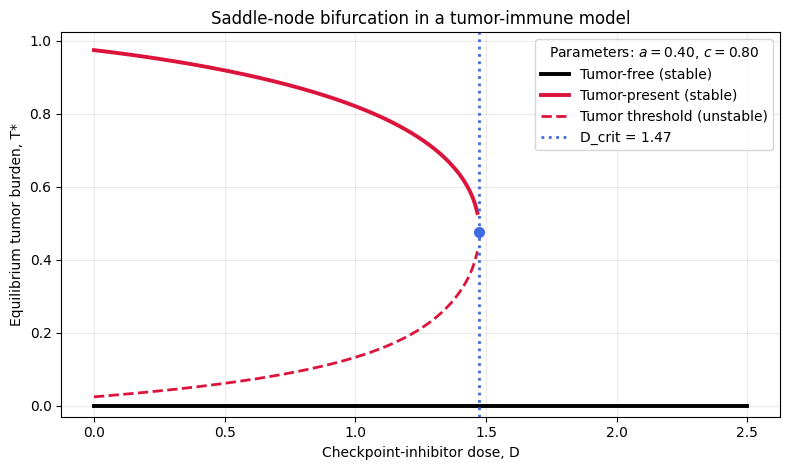

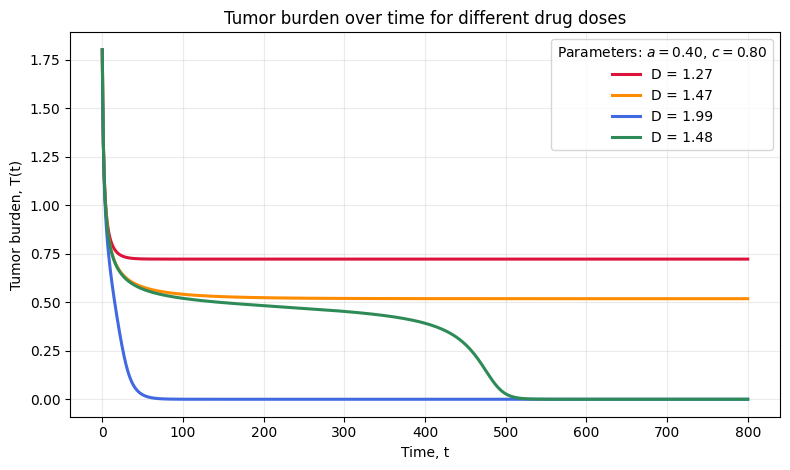

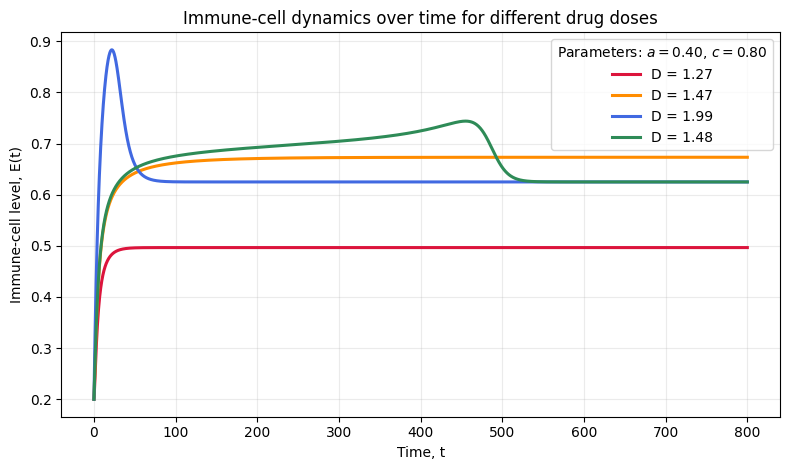

In [ ]:
"""
Saddle-node bifurcation and time simulations for a tumor-immune
checkpoint-inhibitor model.

Outputs:
1. Bifurcation diagram: equilibrium tumor burden T* versus dose D.
2. T(t) for three drug doses.
3. E(t) for the same three drug doses.
"""

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# MODEL PARAMETERS
# =============================================================================

a = 0.40           # a: intrinsic tumor growth rate
K =1.00            # K: carrying capacity
c = 0.80           # c: maximum killing rate
eta = 2.578        # eta: saturation factor 1
gamma = 3.484      # gamma: checkpoint resistance factor
s = 0.25           # s: immune inflow rate
p = 1.272          # p: immune activation proliferation rate
g = 0.944          # g: half-saturation constant for activation
d_e = 0.40         # de: natural death rate of effector cells
mu = 3.210         # mu: exhaustion rate via checkpoint
EC50 = 0.50


# =============================================================================
# MODEL EQUATIONS
# =============================================================================

def drug_effect(D):
    """Checkpoint-inhibitor response f(D), increasing from 0 toward 1."""
    return D / (EC50 + D)


def rhs(T, E, D):
    """
    Return the time derivatives dT/dt and dE/dt.

    dT/dt = a*T*(1 - T/K) - (c*E*T) /
            (1 + eta*T + gamma*(1 - f(D))*T)

    dE/dt = s + (p*E*T)/(g + T) - d_e*E
            - mu*E*T*(1 - f(D))
    """
    f = drug_effect(D)

    denominator = 1.0 + eta * T + gamma * (1.0 - f) * T

    dT_dt = a * T * (1.0 - T / K) - c * E * T / denominator

    dE_dt = (
        s
        + p * E * T / (g + T)
        - d_e * E
        - mu * E * T * (1.0 - f)
    )

    return np.array([dT_dt, dE_dt])


# =============================================================================
# EQUILIBRIUM AND STABILITY FUNCTIONS
# =============================================================================

def immune_level_on_tumor_nullcline(T, D):
    """
    Calculate E from dT/dt = 0 for the positive-tumor branch, T > 0.
    """
    f = drug_effect(D)

    denominator = 1.0 + eta * T + gamma * (1.0 - f) * T

    return a * (1.0 - T / K) * denominator / c


def equilibrium_residual(T, D):
    """
    Substitute E(T, D), obtained from dT/dt = 0, into dE/dt.

    A positive equilibrium occurs where this residual equals zero.
    """
    E = immune_level_on_tumor_nullcline(T, D)
    return rhs(T, E, D)[1]


def bisect(function, left, right, iterations=60):
    """Bisection method for finding a root in an interval."""
    f_left = function(left)

    for _ in range(iterations):
        midpoint = (left + right) / 2.0
        f_midpoint = function(midpoint)

        if f_left * f_midpoint <= 0.0:
            right = midpoint
        else:
            left = midpoint
            f_left = f_midpoint

    return (left + right) / 2.0


def positive_equilibria(D, samples=3000):
    """
    Find all positive equilibria (T*, E*) for a specified dose D.
    """
    T_values = np.linspace(1e-7, K - 1e-7, samples)

    residuals = np.array(
        [equilibrium_residual(T, D) for T in T_values]
    )

    roots = []

    for left, right, f_left, f_right in zip(
        T_values[:-1],
        T_values[1:],
        residuals[:-1],
        residuals[1:]
    ):
        if f_left * f_right < 0.0:
            T_root = bisect(
                lambda T: equilibrium_residual(T, D),
                left,
                right
            )

            E_root = immune_level_on_tumor_nullcline(T_root, D)

            roots.append((T_root, E_root))

    return roots


def jacobian(T, E, D):
    """Return the analytical 2x2 Jacobian matrix."""
    f = drug_effect(D)
    checkpoint_factor = 1.0 - f

    denominator = 1.0 + eta * T + gamma * checkpoint_factor * T
    denominator_slope = eta + gamma * checkpoint_factor

    j11 = (
        a * (1.0 - 2.0 * T / K)
        - c * E / denominator
        + c * E * T * denominator_slope / denominator**2
    )

    j12 = -c * T / denominator

    j21 = (
        p * E * g / (g + T)**2
        - mu * E * checkpoint_factor
    )

    j22 = (
        p * T / (g + T)
        - d_e
        - mu * T * checkpoint_factor
    )

    return np.array([
        [j11, j12],
        [j21, j22]
    ])


def is_stable(T, E, D):
    """Return True if both Jacobian eigenvalues have negative real parts."""
    eigenvalues = np.linalg.eigvals(jacobian(T, E, D))
    return np.all(np.real(eigenvalues) < 0.0)


def minimum_residual(D):
    """
    Find the smallest residual on the positive branch.

    At the saddle-node point, the minimum residual is zero.
    """
    T_values = np.linspace(0.0, K, 6001)

    residuals = np.array(
        [equilibrium_residual(T, D) for T in T_values]
    )

    index = np.argmin(residuals)

    return residuals[index], T_values[index]


# =============================================================================
# TIME INTEGRATION: FOURTH-ORDER RUNGE-KUTTA
# =============================================================================

def simulate_rk4(D, initial_state, t_start, t_end, steps=3000):
    """
    Simulate T(t) and E(t) at a fixed dose D using RK4 integration.
    """
    time = np.linspace(t_start, t_end, steps + 1)
    dt = time[1] - time[0]

    states = np.empty((steps + 1, 2))
    states[0] = initial_state

    for i in range(steps):
        T, E = states[i]

        k1 = rhs(T, E, D)

        k2 = rhs(
            T + dt * k1[0] / 2.0,
            E + dt * k1[1] / 2.0,
            D
        )

        k3 = rhs(
            T + dt * k2[0] / 2.0,
            E + dt * k2[1] / 2.0,
            D
        )

        k4 = rhs(
            T + dt * k3[0],
            E + dt * k3[1],
            D
        )

        states[i + 1] = states[i] + dt * (
            k1 + 2.0 * k2 + 2.0 * k3 + k4
        ) / 6.0

    return time, states


# =============================================================================
# FIND THE SADDLE-NODE CRITICAL DOSE
# =============================================================================

left_D = 0.0
right_D = 2.5

if minimum_residual(left_D)[0] >= 0.0:
    raise RuntimeError("No positive equilibria exist at D = 0.")

if minimum_residual(right_D)[0] < 0.0:
    raise RuntimeError("Increase right_D to bracket the saddle-node point.")

for _ in range(50):
    middle_D = (left_D + right_D) / 2.0

    if minimum_residual(middle_D)[0] < 0.0:
        left_D = middle_D
    else:
        right_D = middle_D

D_crit = (left_D + right_D) / 2.0

_, T_crit = minimum_residual(D_crit)
E_crit = immune_level_on_tumor_nullcline(T_crit, D_crit)

print(f"Estimated saddle-node dose: D_crit = {D_crit:.4f}")
print(f"Collision point: T* = {T_crit:.4f}, E* = {E_crit:.4f}")


# =============================================================================
# BIFURCATION DIAGRAM
# =============================================================================

D_values = np.linspace(0.0, 2.5, 260)

stable_T = np.full(D_values.size, np.nan)
unstable_T = np.full(D_values.size, np.nan)

for i, D in enumerate(D_values):
    equilibria = positive_equilibria(D)

    for T_star, E_star in equilibria:
        if is_stable(T_star, E_star, D):
            stable_T[i] = T_star
        else:
            unstable_T[i] = T_star

fig_bifurcation, ax_bifurcation = plt.subplots(figsize=(8, 4.8))

ax_bifurcation.plot(
    D_values,
    np.zeros_like(D_values),
    "k-",R(T,D)
    linewidth=2.8,
    label="Tumor-free (stable)"
)

ax_bifurcation.plot(
    D_values,
    stable_T,
    color="crimson",
    linewidth=2.8,
    label="Tumor-present (stable)"
)

ax_bifurcation.plot(
    D_values,
    unstable_T,
    color="crimson",
    linestyle="--",
    linewidth=2.0,
    label="Tumor threshold (unstable)"
)

ax_bifurcation.axvline(
    D_crit,
    color="royalblue",
    linestyle=":",
    linewidth=2.0,
    label=f"D_crit = {D_crit:.2f}"
)

ax_bifurcation.plot(
    D_crit,
    T_crit,
    "o",
    color="royalblue",
    markersize=7
)

ax_bifurcation.set_xlabel("Checkpoint-inhibitor dose, D")
ax_bifurcation.set_ylabel("Equilibrium tumor burden, T*")
ax_bifurcation.set_title("Saddle-node bifurcation in a tumor-immune model")
ax_bifurcation.set_ylim(bottom=-0.03)
ax_bifurcation.grid(True, alpha=0.25)
ax_bifurcation.legend(
    title=fr"Parameters: $a={a:.2f}$, $c={c:.2f}$"
)
fig_bifurcation.tight_layout()


# =============================================================================
# TIME SIMULATIONS AT THREE DOSES
# =============================================================================

initial_state = np.array([1.80, 0.20])
t_start = 0.0
t_end = 800.0

drug_doses = [1.27, 1.47, 1.99, 1.48]
colors = ["crimson", "darkorange", "royalblue", "seagreen"]

fig_T, ax_T = plt.subplots(figsize=(8, 4.8))
fig_E, ax_E = plt.subplots(figsize=(8, 4.8))

for dose, color in zip(drug_doses, colors):
    time, states = simulate_rk4(
        dose,
        initial_state,
        t_start,
        t_end
    )

    T_time = states[:, 0]
    E_time = states[:, 1]

    ax_T.plot(
        time,
        T_time,
        color=color,
        linewidth=2.2,
        label=f"D = {dose}"
    )

    ax_E.plot(
        time,
        E_time,
        color=color,
        linewidth=2.2,
        label=f"D = {dose}"
    )


# Graph of T(t)
ax_T.set_xlabel("Time, t")
ax_T.set_ylabel("Tumor burden, T(t)")
ax_T.set_title("Tumor burden over time for different drug doses")
ax_T.grid(True, alpha=0.25)
ax_T.legend(
    title=fr"Parameters: $a={a:.2f}$, $c={c:.2f}$"
)
fig_T.tight_layout()


# Graph of E(t)
ax_E.set_xlabel("Time, t")
ax_E.set_ylabel("Immune-cell level, E(t)")
ax_E.set_title("Immune-cell dynamics over time for different drug doses")
ax_E.grid(True, alpha=0.25)
ax_E.legend(
    title=fr"Parameters: $a={a:.2f}$, $c={c:.2f}$"
)
fig_E.tight_layout()


plt.show()